**Data Understanding & Preparation**

In [ ]:
# Task 1: Data Understanding & Preparation

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load dataset
df = pd.read_csv(
    "Customer Churn Dataset Task 1.csv"
)

print("Shape:", df.shape)
print(df.info())
print("\nChurn distribution:\n", df['churn'].value_counts())

# Handle missing values
df = df.dropna()

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Features & target
X = df.drop('churn', axis=1)
y = df['churn']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Safety check (anti-leakage)
assert 'churn' not in X.columns

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (500, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          500 non-null    object
 1   age                  500 non-null    int64 
 2   gender               500 non-null    object
 3   tenure_months        500 non-null    int64 
 4   monthly_usage_hours  500 non-null    int64 
 5   support_tickets      500 non-null    int64 
 6   subscription_type    500 non-null    object
 7   monthly_charges      500 non-null    int64 
 8   payment_method       500 non-null    object
 9   churn                500 non-null    int64 
dtypes: int64(6), object(4)
memory usage: 39.2+ KB
None

Churn distribution:
 churn
0    349
1    151
Name: count, dtype: int64


,customer_id,age,gender,tenure_months,monthly_usage_hours,support_tickets,subscription_type,monthly_charges,payment_method,churn
0,0,50,1,38,29,4,2,799,1,0
1,1,39,0,33,32,4,0,399,1,0
2,2,25,0,51,32,2,2,799,2,0
3,3,44,1,11,16,3,1,1499,0,0
4,4,46,0,51,46,1,1,1499,2,0


**Exploratory Data Analysis (Professional, Annotated & Aligned)**

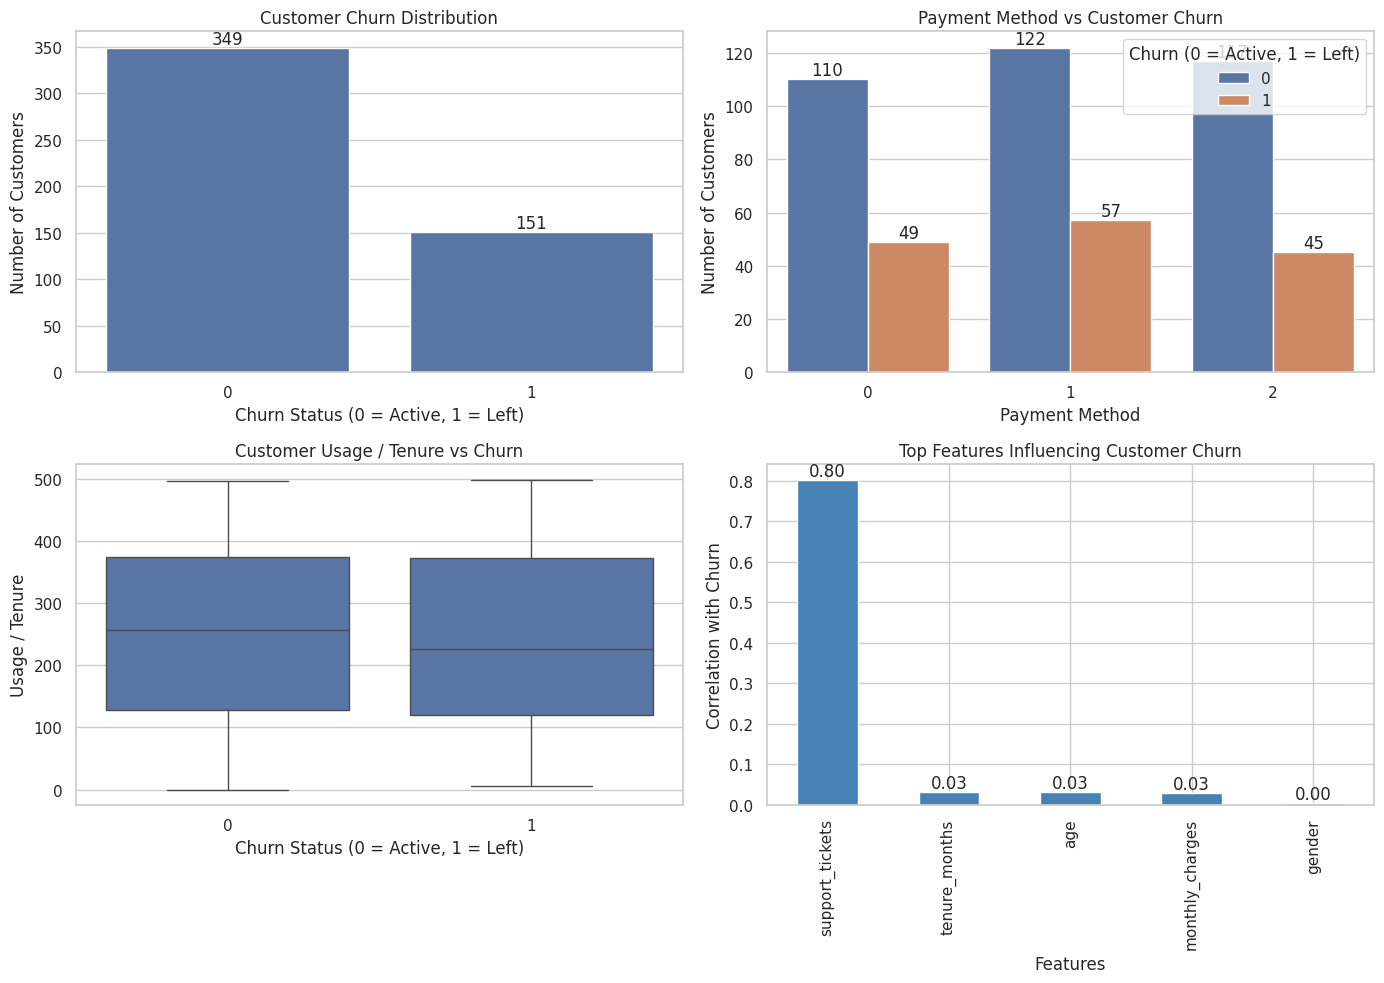

In [ ]:
# Task 2: Exploratory Data Analysis (Professional, Annotated & Aligned)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")

# -------------------------------
# 1. CHURN DISTRIBUTION (BAR)
# -------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14,10))

ax1 = sns.countplot(x='churn', data=df, ax=axes[0,0])
ax1.set_title("Customer Churn Distribution")
ax1.set_xlabel("Churn Status (0 = Active, 1 = Left)")
ax1.set_ylabel("Number of Customers")

for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', label_type='edge')


# -------------------------------
# 2. PAYMENT METHOD vs CHURN (GROUPED BAR)
# -------------------------------
ax2 = sns.countplot(
    x='payment_method',
    hue='churn',
    data=df,
    ax=axes[0,1]
)

ax2.set_title("Payment Method vs Customer Churn")
ax2.set_xlabel("Payment Method")
ax2.set_ylabel("Number of Customers")

for container in ax2.containers:
    ax2.bar_label(container, fmt='%d', label_type='edge')

ax2.legend(title="Churn (0 = Active, 1 = Left)")


# -------------------------------
# 3. USAGE / TENURE vs CHURN (BOXPLOT)
# -------------------------------
usage_col = df.columns[0]   # replace if you know exact column

ax3 = sns.boxplot(
    x='churn',
    y=usage_col,
    data=df,
    ax=axes[1,0]
)

ax3.set_title("Customer Usage / Tenure vs Churn")
ax3.set_xlabel("Churn Status (0 = Active, 1 = Left)")
ax3.set_ylabel("Usage / Tenure")


# -------------------------------
# 4. TOP FEATURES INFLUENCING CHURN (BAR)
# -------------------------------
churn_corr = df.corr()['churn'].sort_values(ascending=False)[1:6]

ax4 = churn_corr.plot(
    kind='bar',
    ax=axes[1,1],
    color='steelblue'
)

ax4.set_title("Top Features Influencing Customer Churn")
ax4.set_xlabel("Features")
ax4.set_ylabel("Correlation with Churn")

for p in ax4.patches:
    ax4.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

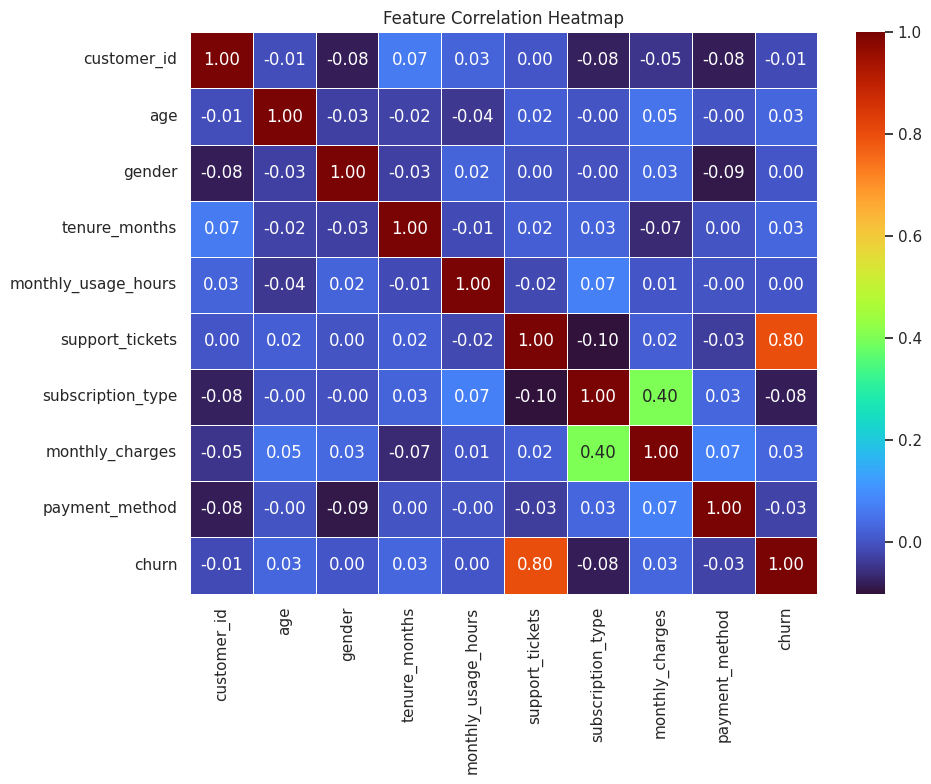

In [ ]:
# -------------------------------
# 5. CORRELATION HEATMAP (ANNOTATED)
# -------------------------------
plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="turbo",
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
test_data = df["churn"]
features=['age', 'gender', 'tenure_months', 'monthly_usage_hours',
       'subscription_type', 'monthly_charges','payment_method']
train_data = df[features]
x_train, x_test, y_train, y_test = train_test_split(train_data, test_data, test_size=0.2, random_state=42)

**Feature Engineering**

In [ ]:
# Task 3: Feature Engineering

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Feature importance ONLY on training data
rf_temp = RandomForestClassifier(random_state=42)
rf_temp.fit(X_train, y_train)

feature_importance = pd.Series(
    rf_temp.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature Importance:\n")
feature_importance

Feature Importance:



,0
customer_id,0.213040
tenure_months,0.187647
monthly_usage_hours,0.185540
age,0.161724
support_tickets,0.097946
payment_method,0.050561
monthly_charges,0.035967
subscription_type,0.035923
gender,0.031651


**Model Development & Training**

In [ ]:
# Task 4: Model Development & Training

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Models
lr =LogisticRegression(max_iter=1000,random_state=42,class_weight="balanced")
rf = RandomForestClassifier(random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)  # standard choice

# Train models
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
knn.fit(X_train, y_train)

# Predictions
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
knn_pred = knn.predict(X_test)

**Model Evaluation & Interpretation**

Logistic Regression
Accuracy : 0.42
Precision: 0.21568627450980393
Recall   : 0.3793103448275862
F1-Score : 0.275
Unique predictions: [0 1]


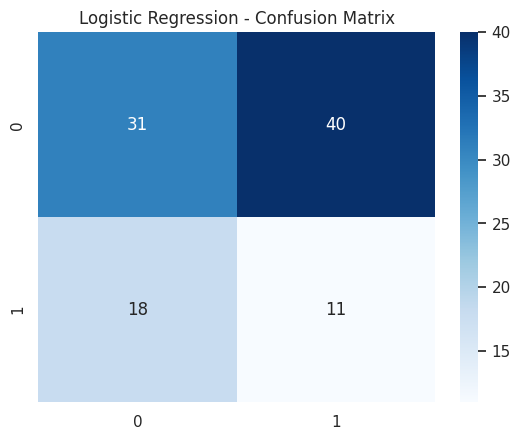

Random Forest
Accuracy : 0.69
Precision: 0.3333333333333333
Recall   : 0.06896551724137931
F1-Score : 0.11428571428571428
Unique predictions: [0 1]


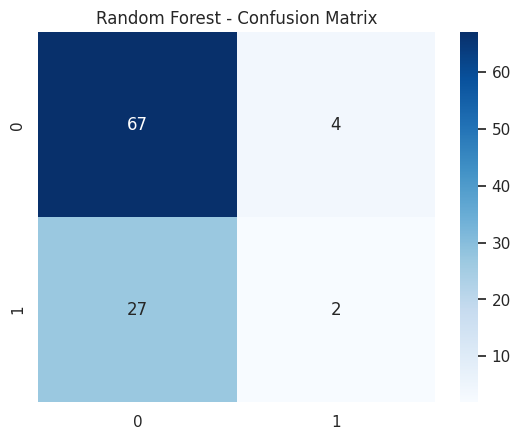

K-Nearest Neighbors
Accuracy : 0.63
Precision: 0.1
Recall   : 0.034482758620689655
F1-Score : 0.05128205128205128
Unique predictions: [0 1]


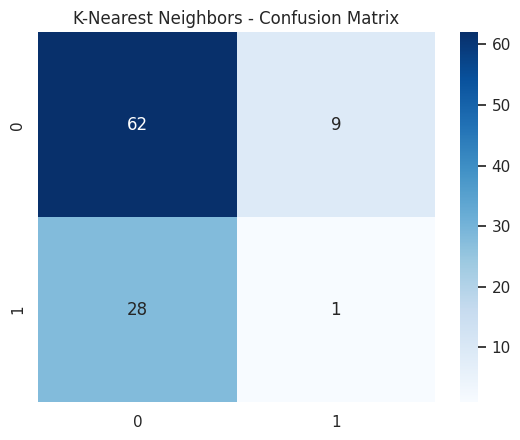


Model Comparison Table:



,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.42,0.215686,0.379310,0.275000
1,Random Forest,0.69,0.333333,0.068966,0.114286
2,K-Nearest Neighbors,0.63,0.100000,0.034483,0.051282


In [ ]:
# Task 5: Model Evaluation & Interpretation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

models = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "K-Nearest Neighbors": knn_pred
}

results = []

for name, preds in models.items():
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    results.append([name, acc, prec, rec, f1])

    print("="*55)
    print(name)
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-Score :", f1)
    print("Unique predictions:", np.unique(preds))

    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

print("\nModel Comparison Table:\n")
results_df

**Insight Generation & Business Interpretation**

In [ ]:
# Task 6: Insight Generation & Business Interpretation

best_model = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]

print("FINAL BEST MODEL SELECTION")
print("-"*40)
print("Best Algorithm 🏆 :", best_model["Model"])
print("Accuracy       :", best_model["Accuracy"])
print("Precision      :", best_model["Precision"])
print("Recall         :", best_model["Recall"])
print("F1-Score       :", best_model["F1-Score"])



FINAL BEST MODEL SELECTION
----------------------------------------
Best Algorithm 🏆 : Random Forest
Accuracy       : 0.69
Precision      : 0.3333333333333333
Recall         : 0.06896551724137931
F1-Score       : 0.11428571428571428


**Final Prediction Summary using Logistic Regression**

In [ ]:
# ================================
# FINAL PREDICTION SUMMARY
# Using Random Forest
# ================================

import numpy as np

# 1. Get churn probabilities from Random Forest
rf_probs = rf.predict_proba(X_test)[:, 1]   # probability of churn (class = 1)

# 2. Apply business threshold
threshold = 0.4   # you can keep same threshold for fair comparison
rf_predictions = (rf_probs >= threshold).astype(int)

# 3. Count predictions
total_customers = len(rf_predictions)
stay_count = (rf_predictions == 0).sum()
leave_count = (rf_predictions == 1).sum()

# 4. Convert to percentages
stay_percent = (stay_count / total_customers) * 100
leave_percent = (leave_count / total_customers) * 100

# 5. Print final result
print("Overall Customer Churn Prediction Summary (Random Forest)")
print("-" * 55)
print(f"Customers likely to STAY  : {stay_percent:.2f}%")
print(f"Customers likely to LEAVE : {leave_percent:.2f}%")

Overall Customer Churn Prediction Summary (Random Forest)
-------------------------------------------------------
Customers likely to STAY  : 82.00%
Customers likely to LEAVE : 18.00%
